In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from scipy import stats

In [135]:
# generate data
np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1) # y = 4 + 3X + e
data = pd.DataFrame(data=np.hstack((X, y)), columns=['feature', 'target'])

# split data
X_train, X_test, y_train, y_test = train_test_split(data['feature'], data['target'], test_size=20, random_state=42)

# fit model
model = LinearRegression()
model.fit(X_train.values.reshape(-1, 1), y_train)

# predict
y_pred = model.predict(X_test.values.reshape(-1, 1))

# evaluation
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("\n" + "=" * 50)
print("MODEL ACCURACY")
print("=" * 50)
print(f"Intercept: {model.intercept_:.4f}")
print(f"Coefficient: {model.coef_[0]:.4f}")
print()
print(f"R² Score: {r2:.4f}")
print(f"Model explains {r2:.2%} of the variance")
print('✅ Excellent' if r2 > 0.8 else '✅ Good' if r2 > 0.7 else '⚠️ Needs improvement')
print()
print(f"MSE (0 to ∞ lower is better): {mse:.4f}")
print(f"RMSE (0 to ∞ lower is better): {rmse:.4f}")


MODEL ACCURACY
Intercept: 4.1429
Coefficient: 2.7993

R² Score: 0.8072
Model explains 80.72% of the variance
✅ Excellent

MSE (0 to ∞ lower is better): 0.6537
RMSE (0 to ∞ lower is better): 0.8085


In [127]:
# 1. DATA EXPLORATION
print("=" * 50)
print("DATA OVERVIEW")
print("=" * 50)
print(data.head())
print(f"\nData shape: {data.shape}")
print(f"Stats:\n{data.describe()}")

# 2. CHECK FOR MISSING VALUES
print("\n" + "=" * 50)
print("MISSING VALUES")
print("=" * 50)
print(data.isnull().sum())

# 3. CORRELATION
print("\n" + "=" * 50)
print("CORRELATION")
print("=" * 50)
print(f"Correlation between feature and target: \n{data.corr()}")
print(f"Correlation between feature and target: {data.corr().iloc[0, 1]:.4f}")

DATA OVERVIEW
    feature    target
0  0.749080  6.334288
1  1.901429  9.405278
2  1.463988  8.483724
3  1.197317  5.604382
4  0.312037  4.716440

Data shape: (100, 2)
Stats:
          feature      target
count  100.000000  100.000000
mean     0.940361    6.820004
std      0.594979    1.879138
min      0.011044    3.238062
25%      0.386402    5.302794
50%      0.928285    6.676056
75%      1.460406    8.297638
max      1.973774   11.044395

MISSING VALUES
feature    0
target     0
dtype: int64

CORRELATION
Correlation between feature and target: 
          feature    target
feature  1.000000  0.877082
target   0.877082  1.000000
Correlation between feature and target: 0.8771


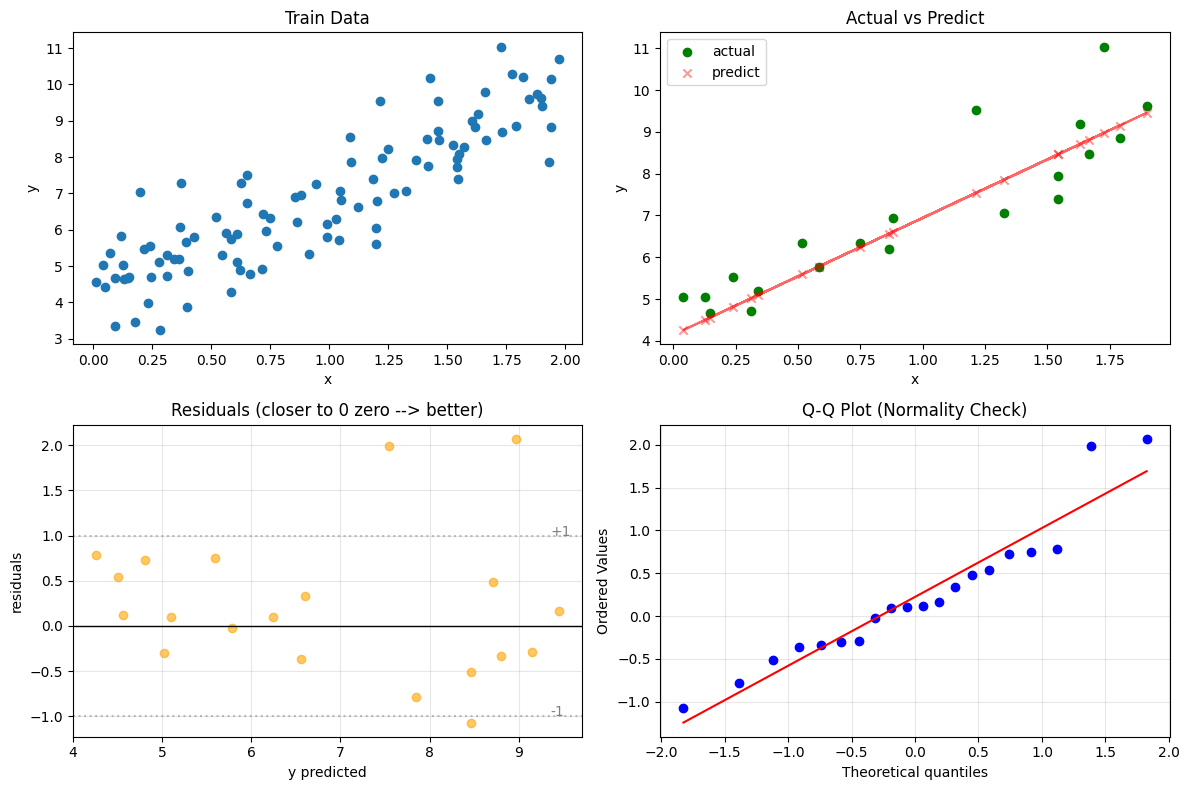

In [110]:
plt.figure(figsize=(12, 8))

# plot 1
plt.subplot(2, 2, 1)
plt.scatter(x=X, y=y)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Train Data')

# plot 2
plt.subplot(2, 2, 2)
plt.scatter(x=X_test, y=y_test, label='actual', color='green')
plt.scatter(x=X_test, y=y_pred, label='predict', color='red', marker='x', alpha=0.4)
plt.plot(X_test, y_pred, color='red', linestyle='-', alpha=0.6)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Actual vs Predict')
plt.legend()

# plot 3
plt.subplot(2, 2, 3)
residuals = y_test - y_pred
plt.scatter(y_pred, residuals, color='orange', alpha=0.6)
plt.axhline(y=0, color='black', linestyle='-', linewidth=1)
plt.xlabel('y predicted')
plt.ylabel('residuals')
plt.title('Residuals (closer to 0 zero --> better)')
plt.grid(True, alpha=0.3)

plt.axhline(y=1, color='gray', linestyle=':', alpha=0.5)
plt.axhline(y=-1, color='gray', linestyle=':', alpha=0.5)
plt.text(max(y_pred) - 0.1, 1, '+1', color='gray')
plt.text(max(y_pred) - 0.1, -1, '-1', color='gray')

# plot 4
plt.subplot(2, 2, 4)
stats.probplot(residuals, dist='norm', plot=plt)
plt.title('Q-Q Plot (Normality Check)')
plt.grid(True, alpha=0.3)

plt.tight_layout()

Residual = Actual Value - Predicted Value

Residual = 0 → Perfect prediction (actual = predicted)

Residual > 0 → Model under-predicted (actual is higher than predicted)

Residual < 0 → Model over-predicted (actual is lower than predicted)

In [102]:
residuals = y_test - y_pred
print(f"Mean of residuals: {np.mean(residuals):.4f}")  # Should be ~0
print(f"Std of residuals: {np.std(residuals):.4f}")

Mean of residuals: 0.2236
Std of residuals: 0.7770


In [138]:
# percentage of residuals close to 0
close_to_zero = np.abs(residuals) < 1  # Within 1 units
percentage = np.mean(close_to_zero) * 100
print(f"{percentage:.1f}% of predictions are within 1 units of actual value")

85.0% of predictions are within 1 units of actual value
